<a href="https://colab.research.google.com/github/shivanisrivastava421-commits/CBC-Analayser/blob/main/Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("/content/loan_dataset_20000.csv")

In [4]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [6]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [7]:
df.isnull()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df['loan_paid_back'].value_counts()

,count
loan_paid_back,
1,15998
0,4002


Almost 80% of the loans are paid by the borrower.


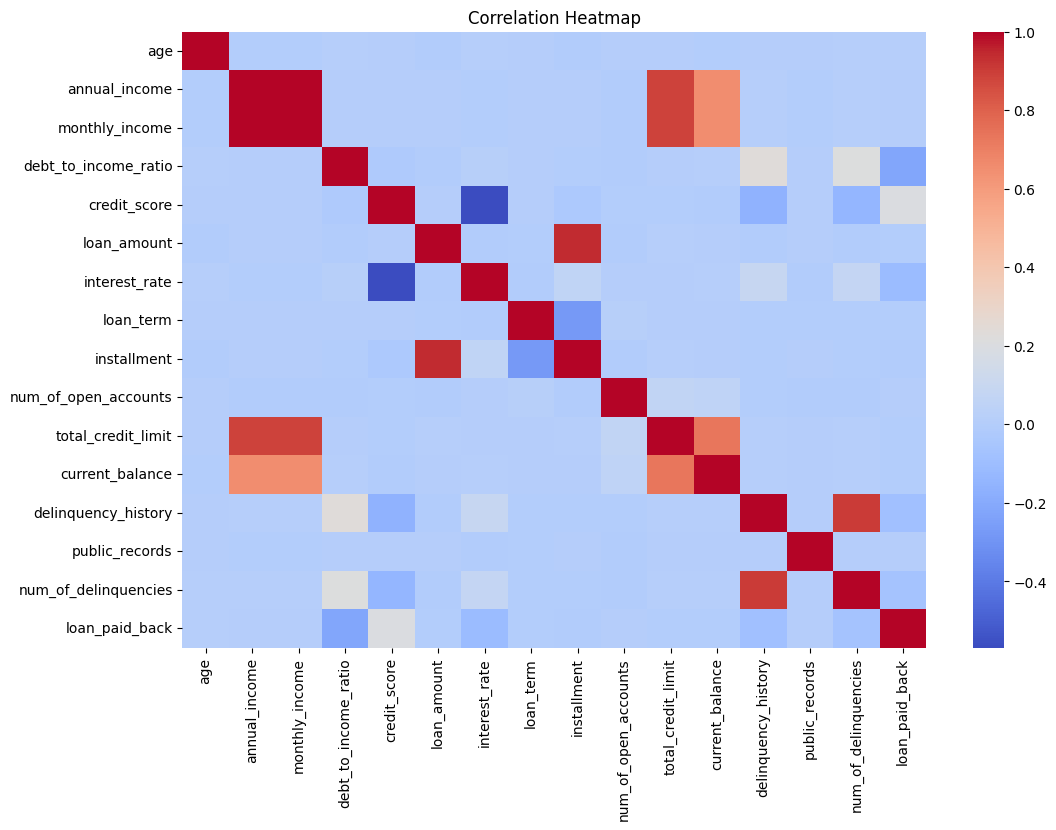

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop("loan_paid_back", axis=1)
y = df["loan_paid_back"]

In [12]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [14]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("Test distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 loan_paid_back
1    0.799875
0    0.200125
Name: proportion, dtype: float64
Test distribution:
 loan_paid_back
1    0.8
0    0.2
Name: proportion, dtype: float64


In [15]:
DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight = {0:3, 1:1},
    random_state=42
)

DecisionTreeClassifier(class_weight={0: 3, 1: 1}, max_depth=5,
                       min_samples_split=10, random_state=42)

In [16]:
model=DecisionTreeClassifier(
    max_depth=5,              # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight = {0:3, 1:1},
    random_state=42
)

In [17]:
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight={0: 3, 1: 1}, max_depth=5,
                       min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [4,5,6,7],
    'min_samples_split': [10,20,30],
    'min_samples_leaf': [5,10,20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

In [19]:
y_pred = model.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8425


In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.67      0.63       800
           1       0.91      0.89      0.90      3200

    accuracy                           0.84      4000
   macro avg       0.75      0.78      0.76      4000
weighted avg       0.85      0.84      0.85      4000



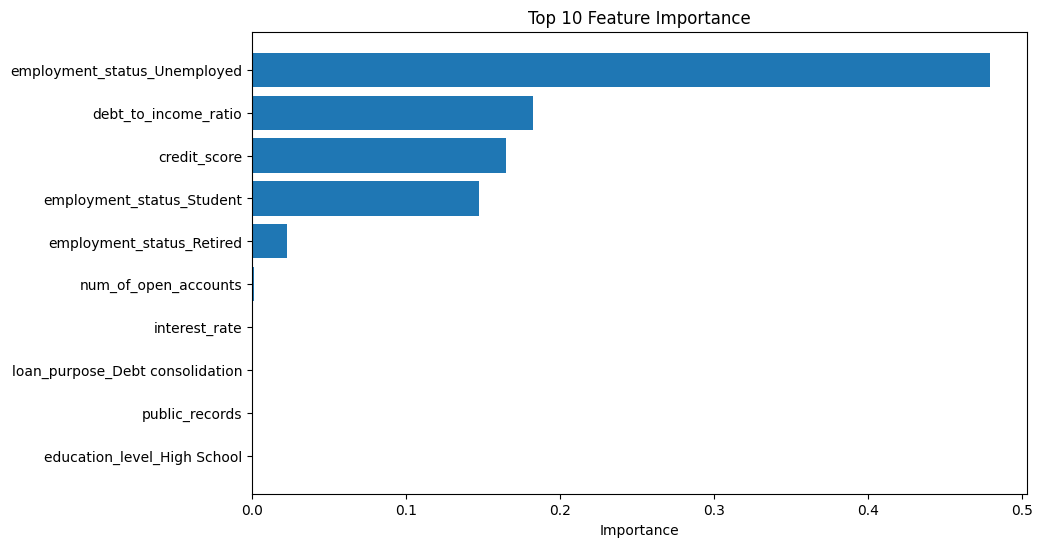

In [23]:

importances = model.feature_importances_
features = X.columns
feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

feat_df = feat_df.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(feat_df["feature"], feat_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

In [24]:
!pip install shap

In [25]:
import shap
shap.initjs()

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

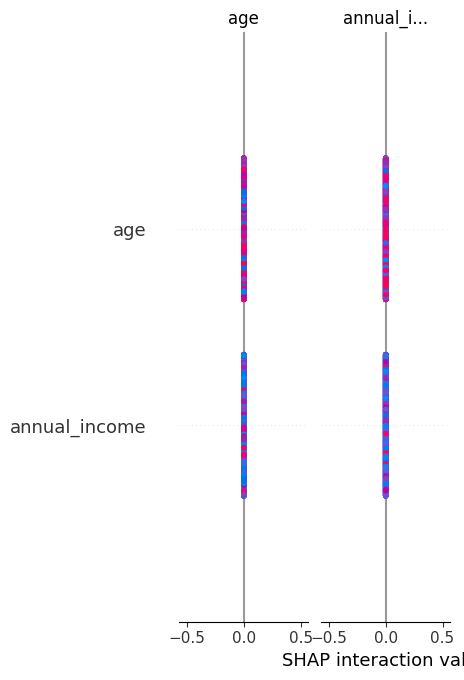

In [27]:
shap.summary_plot(shap_values, X_test)